# Ouvidoria Inteligente — Chunking de Manifestações Longas

Este notebook analisa diferentes estratégias de divisão de textos longos em chunks, utilizando as cinco maiores manifestações da base.

Serão comparadas diferentes configurações de tamanho e sobreposição dos chunks, além da representação dos segmentos no espaço vetorial.

In [24]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

In [25]:
caminho_json = Path("../manifestacoes.json")

with open(caminho_json, "r", encoding="utf-8") as arquivo:
    manifestacoes = json.load(arquivo)

df = pd.DataFrame(manifestacoes)

print(f"Total de manifestações: {len(df)}")

df.head()

Total de manifestações: 40


,id,data,categoria_oficial,texto
0,M001,2026-08-01,infraestrutura,"Há um buraco profundo na Rua das Palmeiras, pr..."
1,M002,2026-08-02,educação,A escola municipal do bairro Jardim Novo está ...
2,M003,2026-08-03,infraestrutura,"Existe um buraco enorme na Av. Brasil, perto d..."
3,M004,2026-08-04,meio ambiente,Moradores estão descartando lixo e entulho às ...
4,M005,2026-08-05,segurança,A praça do bairro Primavera fica muito escura ...


In [26]:
df["tamanho_texto"] = df["texto"].str.len()

df_longas = (
    df.nlargest(5, "tamanho_texto")
    [["id", "categoria_oficial", "texto", "tamanho_texto"]]
    .reset_index(drop=True)
)

df_longas

,id,categoria_oficial,texto,tamanho_texto
0,M033,saúde,Gostaria de relatar a situação enfrentada na u...,776
1,M034,infraestrutura,Venho solicitar providências para a Rua das Ma...,655
2,M036,meio ambiente,A situação do terreno localizado atrás do conj...,651
3,M035,educação,Pais e responsáveis da Escola Municipal Caminh...,636
4,M037,segurança,Os moradores do bairro Nova Esperança pedem at...,615


In [27]:
for _, linha in df_longas.iterrows():
    print(f"\n{linha['id']} — {linha['tamanho_texto']} caracteres")
    print(linha["texto"])
    print("-" * 80)


M033 — 776 caracteres
Gostaria de relatar a situação enfrentada na unidade de saúde do bairro Boa Vista. Nas últimas semanas, moradores têm chegado antes das seis horas da manhã para tentar uma consulta e encontram uma fila muito grande. Muitas pessoas são idosas ou possuem doenças crônicas e permanecem em pé por bastante tempo. Quando o atendimento começa, a equipe informa que existem poucas fichas disponíveis e vários pacientes precisam retornar em outro dia. Além disso, há relatos de falta de alguns medicamentos de uso contínuo na farmácia da unidade. Solicitamos avaliação da quantidade de profissionais, melhoria na organização das filas e regularização do fornecimento de medicamentos para evitar que os moradores precisem se deslocar repetidas vezes sem conseguir atendimento adequado.
--------------------------------------------------------------------------------

M034 — 655 caracteres
Venho solicitar providências para a Rua das Mangueiras, onde os problemas de drenagem têm causad

In [28]:
configuracoes = [
    {
        "nome": "Configuração 1",
        "chunk_size": 200,
        "chunk_overlap": 40
    },
    {
        "nome": "Configuração 2",
        "chunk_size": 350,
        "chunk_overlap": 70
    }
]

pd.DataFrame(configuracoes)

,nome,chunk_size,chunk_overlap
0,Configuração 1,200,40
1,Configuração 2,350,70


In [29]:
def dividir_texto(texto, chunk_size, chunk_overlap):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""]
    )

    return splitter.split_text(texto)

In [30]:
resultados_chunking = []

for configuracao in configuracoes:
    for _, linha in df_longas.iterrows():

        chunks = dividir_texto(
            linha["texto"],
            configuracao["chunk_size"],
            configuracao["chunk_overlap"]
        )

        resultados_chunking.append({
            "Configuração": configuracao["nome"],
            "ID": linha["id"],
            "Tamanho do texto": linha["tamanho_texto"],
            "Quantidade de chunks": len(chunks),
            "Chunks": chunks
        })

df_chunking = pd.DataFrame(resultados_chunking)

df_chunking[
    [
        "Configuração",
        "ID",
        "Tamanho do texto",
        "Quantidade de chunks"
    ]
]

,Configuração,ID,Tamanho do texto,Quantidade de chunks
0,Configuração 1,M033,776,7
1,Configuração 1,M034,655,5
2,Configuração 1,M036,651,5
3,Configuração 1,M035,636,5
4,Configuração 1,M037,615,5
5,Configuração 2,M033,776,3
6,Configuração 2,M034,655,2
7,Configuração 2,M036,651,3
8,Configuração 2,M035,636,2
9,Configuração 2,M037,615,3


In [31]:
comparacao = (
    df_chunking
    .pivot(
        index="ID",
        columns="Configuração",
        values="Quantidade de chunks"
    )
    .reset_index()
)

comparacao

Configuração,ID,Configuração 1,Configuração 2
0,M033,7,3
1,M034,5,2
2,M035,5,2
3,M036,5,3
4,M037,5,3


In [32]:
for _, linha in df_chunking.iterrows():
    print(f"\n{linha['Configuração']} — {linha['ID']}")
    print(f"Quantidade de chunks: {linha['Quantidade de chunks']}")

    for numero, chunk in enumerate(linha["Chunks"], start=1):
        print(f"\nChunk {numero}:")
        print(chunk)

    print("\n" + "=" * 80)


Configuração 1 — M033
Quantidade de chunks: 7

Chunk 1:
Gostaria de relatar a situação enfrentada na unidade de saúde do bairro Boa Vista

Chunk 2:
. Nas últimas semanas, moradores têm chegado antes das seis horas da manhã para tentar uma consulta e encontram uma fila muito grande

Chunk 3:
. Muitas pessoas são idosas ou possuem doenças crônicas e permanecem em pé por bastante tempo

Chunk 4:
. Quando o atendimento começa, a equipe informa que existem poucas fichas disponíveis e vários pacientes precisam retornar em outro dia

Chunk 5:
. Além disso, há relatos de falta de alguns medicamentos de uso contínuo na farmácia da unidade

Chunk 6:
. Solicitamos avaliação da quantidade de profissionais, melhoria na organização das filas e regularização do fornecimento de medicamentos para evitar que os moradores precisem se deslocar repetidas

Chunk 7:
precisem se deslocar repetidas vezes sem conseguir atendimento adequado.


Configuração 1 — M034
Quantidade de chunks: 5

Chunk 1:
Venho solici

In [33]:
modelo_nome = "paraphrase-multilingual-MiniLM-L12-v2"

modelo = SentenceTransformer(modelo_nome)

print("Modelo carregado:", modelo_nome)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modelo carregado: paraphrase-multilingual-MiniLM-L12-v2


In [34]:
dados_chunks = []

for _, linha in df_chunking.iterrows():
    if linha["Configuração"] == "Configuração 1":
        for numero, chunk in enumerate(linha["Chunks"], start=1):
            dados_chunks.append({
                "ID": linha["ID"],
                "Chunk": numero,
                "Texto": chunk
            })

df_chunks_pca = pd.DataFrame(dados_chunks)

print(f"Total de chunks: {len(df_chunks_pca)}")

df_chunks_pca.head()

Total de chunks: 27


,ID,Chunk,Texto
0,M033,1,Gostaria de relatar a situação enfrentada na u...
1,M033,2,". Nas últimas semanas, moradores têm chegado a..."
2,M033,3,. Muitas pessoas são idosas ou possuem doenças...
3,M033,4,". Quando o atendimento começa, a equipe inform..."
4,M033,5,". Além disso, há relatos de falta de alguns me..."


In [35]:
embeddings_chunks = modelo.encode(
    df_chunks_pca["Texto"].tolist(),
    convert_to_numpy=True
)

print("Formato dos embeddings:", embeddings_chunks.shape)

Formato dos embeddings: (27, 384)


In [36]:
pca = PCA(n_components=2)

coordenadas_pca = pca.fit_transform(embeddings_chunks)

df_chunks_pca["PCA 1"] = coordenadas_pca[:, 0]
df_chunks_pca["PCA 2"] = coordenadas_pca[:, 1]

df_chunks_pca.head()

,ID,Chunk,Texto,PCA 1,PCA 2
0,M033,1,Gostaria de relatar a situação enfrentada na u...,1.108891,-0.265887
1,M033,2,". Nas últimas semanas, moradores têm chegado a...",1.081132,0.017522
2,M033,3,. Muitas pessoas são idosas ou possuem doenças...,1.500785,1.166280
3,M033,4,". Quando o atendimento começa, a equipe inform...",1.889499,1.366802
4,M033,5,". Além disso, há relatos de falta de alguns me...",1.691333,1.987825


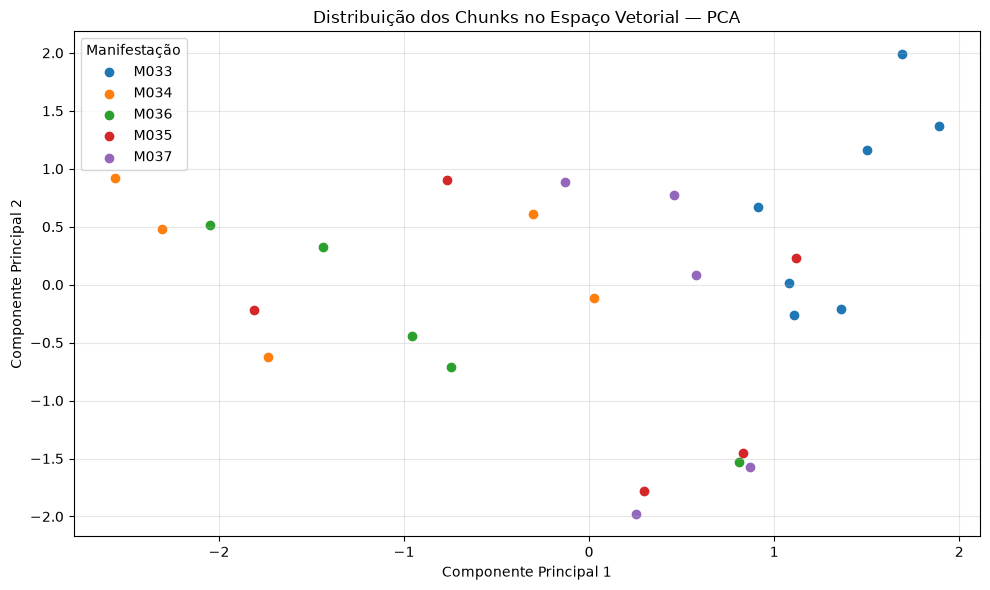

In [37]:
plt.figure(figsize=(10, 6))

for id_manifestacao in df_chunks_pca["ID"].unique():
    dados = df_chunks_pca[
        df_chunks_pca["ID"] == id_manifestacao
    ]

    plt.scatter(
        dados["PCA 1"],
        dados["PCA 2"],
        label=id_manifestacao
    )

plt.title("Distribuição dos Chunks no Espaço Vetorial — PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Manifestação")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Análise do Chunking

A **Configuração 1 (200/40)** gerou mais chunks, permitindo uma divisão mais detalhada dos textos. A **Configuração 2 (350/70)** produziu menos chunks e preservou trechos maiores, reduzindo a fragmentação do conteúdo.

O overlap ajuda a manter o contexto entre chunks consecutivos, embora aumente a repetição de informações. Neste conjunto, a Configuração 2 preserva melhor trechos maiores, enquanto a Configuração 1 oferece maior granularidade.

Na visualização por PCA, alguns chunks da mesma manifestação aparecem próximos, mas não formam grupos totalmente separados. Também ocorre sobreposição entre manifestações, indicando que diferentes trechos podem compartilhar características semânticas.